# A. Data

In [1]:
import pandas as pd

In [2]:
file_path = "listings_newyork.xlsx"
listing = pd.read_excel(file_path)
listing.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,40824219,https://www.airbnb.com/rooms/40824219,20251001171547,2025-10-02,city scrape,Room close to Manhattan for FEMALE guests,This cozy spacious room includes a twin size b...,Sunnyside is a safe residental area. <br />The...,https://a0.muscache.com/pictures/hosting/Hosti...,317540555,...,4.88,4.94,4.69,NaN,f,3,0,3,0,0.23
1,40833186,https://www.airbnb.com/rooms/40833186,20251001171547,2025-10-02,previous scrape,Soho LES East village private room downtown,NaN,NaN,https://a0.muscache.com/pictures/1f093bbc-936c...,68718914,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
2,40837137,https://www.airbnb.com/rooms/40837137,20251001171547,2025-10-02,previous scrape,Sunset Park - Quiet and close to subway!,"Cozy, lovely bedroom with a comfortable full s...",the sunset park of Brooklyn,https://a0.muscache.com/pictures/01c4e91e-4012...,317770098,...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.01
3,40838018,https://www.airbnb.com/rooms/40838018,20251001171547,2025-10-02,previous scrape,Cozy One Bedroom in Clinton Hill,This sunny one-bedroom apartment is located in...,Clinton Hill is one of the best neighborhoods ...,https://a0.muscache.com/pictures/9322d54a-6eb7...,17211451,...,5.00,5.00,5.00,NaN,t,1,1,0,0,0.01
4,40839416,https://www.airbnb.com/rooms/40839416,20251001171547,2025-10-02,city scrape,ðŸª´XL dojo ðŸŒ¾ shared green yogi palace apt ...,"New York City living at its best. A massive, c...",Live like the Ramones > The East Village is st...,https://a0.muscache.com/pictures/hosting/Hosti...,4765305,...,5.00,5.00,4.95,NaN,f,8,0,8,0,0.40


In [3]:
listing.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [4]:
listing.shape

(36111, 79)

# B. Preproccesing

## 1. Data cleansing and transformation

### 1.1. Drop meaningless columns

Dropping columns that have no predictive signal/impossible to transform:
1. Pure identification/URL columns: 'id', 'listing_url', 'scrape_id', 'host_id', 'host_url', 'picture_url', 'host_thumbnail_url', 'host_picture_url'
2. Long unstructured text which are not relevant to the prediction: 'name', 'description', 'host_name', 'host_since', 'host_about', 'neighborhood_overview', 'host_about', 'host_verifications', 'source'
4. High-cardinality, overly specific location fields: 'host_location',
'host_neighbourhood', 'neighbourhood',  'neighbourhood_cleansed' (we keep only 'neighbourhood_group_cleansed' as it shows the aggregate data)
5. Redundant/overlapping columns (as they are sub-components of the same thing):
   * 'property_type' --> keep 'room_type' only (because room_type is more representative, showing the types of property)
   * 'host_listings_count' --> keep 'host_total_listings_count' only
6. Columns with extremely high missingness: 'license'
7. Machine-generated timing fields (these are internal system timestamps → irrelevant to Superhost prediction): 'calendar_updated', 'calendar_last_scraped', 'last_scraped' (we may use 'last_scraped' together with 'first_review' and 'last_review' to calculate the total time the listings have been reviewd on Airbnb, then we drop those columns later)

In [5]:
listing["property_type"].value_counts()

property_type
Entire rental unit             15253
Private room in rental unit     9852
Private room in home            2629
Room in hotel                   1426
Entire home                     1247
                               ...  
Private room in in-law             1
Private room in tent               1
Entire bed and breakfast           1
Cave                               1
Dome                               1
Name: count, Length: 74, dtype: int64

In [6]:
listing["calculated_host_listings_count_entire_homes"].isnull().sum()

0

In [7]:
listing["calculated_host_listings_count_private_rooms"].isnull().sum()

0

In [8]:
listing["calculated_host_listings_count_shared_rooms"].isnull().sum()

0

In [9]:
listing.drop(columns=[
    'id', 'listing_url', 'scrape_id', 'host_id', 'host_url', 'picture_url', 'host_thumbnail_url', 'host_picture_url',
    'name', 'description', 'host_name', 'neighborhood_overview', 'host_verifications', 'source',
    'host_location', 'host_neighbourhood', 'neighbourhood', 'neighbourhood_cleansed',
    'property_type', 'host_listings_count', 'license', 'calendar_updated', 'calendar_last_scraped', 'host_since', 'host_about'
], inplace=True)   

In [10]:
listing.columns

Index(['last_scraped', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text',
       'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review',
       'last_review', 'review_scores_rating', 'review_scores_accuracy',
       'review_sc

In [11]:
listing.shape

(36111, 54)

### 1.2. Data transformations

#### a. Convert 'amenities' to 'amenities_count'

This will be better instead of dropping this column out of our dataset because
* The number of amenities strongly reflects listing quality --> affects guest satisfaction --> affects review scores --> affects chances of being Superhost.

In [12]:
listing["amenities"]

0        ["Extra pillows and blankets", "Dedicated work...
1        ["Hot water", "Air conditioning", "Wifi", "TV"...
2        ["Smoke alarm", "Kitchen", "Hair dryer", "Wifi...
3        ["Hot water", "Smoke alarm", "Air conditioning...
4        ["Dedicated workspace", "Microwave", "Elevator...
                               ...                        
36106    ["Hot water", "Wifi", "Dryer \u2013\u00a0In un...
36107    ["Dedicated workspace", "Bathtub", "Elevator",...
36108    ["Clothing storage", "Extra pillows and blanke...
36109    ["Hot water", "Smoke alarm", "Pets allowed", "...
36110    ["Hot water", "Smoke alarm", "Pets allowed", "...
Name: amenities, Length: 36111, dtype: object

In [13]:
import ast
import pandas as pd

def count_amenities(x):
    # Case 1: already a Python list
    if isinstance(x, list):
        return len(x)
    
    # Case 2: it's a string
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return 0
        try:
            # Try to interpret it as a Python-style list string
            items = ast.literal_eval(s)
            return len(items)
        except Exception:
            # Fallback: treat it as a comma-separated string
            return len([a for a in s.split(',') if a.strip() != ""])
    
    # Case 3: NaN or anything else
    return 0

listing['amenities_count'] = listing['amenities'].apply(count_amenities)

In [14]:
listing["amenities_count"].head()

0    29
1     8
2     9
3    10
4    37
Name: amenities_count, dtype: int64

In [15]:
listing.drop(columns=['amenities'], inplace=True)

#### b. Convert data variables --> numeric features

##### *review recency 

* last_scraped - first_review = how long it has been since the host got their first review
  
--> Transform to 'days_since_first_rv'

* last_scraped - last_review = how long since their most recent review
  
--> Transform to 'days_since_last_rv'

These can be strong predictors because:
* Superhosts must have consistent bookings
* If last review is long ago → low activity → less likely Superhost

In [16]:
#convert to datetime
listing["first_review"] = pd.to_datetime(listing["first_review"], errors = 'coerce')
listing["last_review"] = pd.to_datetime(listing["last_review"], errors = 'coerce')

In [17]:
#days since first review
listing["days_since_first_rv"] = (listing['last_scraped'] - listing['first_review']).dt.days
#days since last review
listing['days_since_last_rv'] = (listing['last_scraped'] - listing['last_review']).dt.days

In [18]:
#drop the original date columns
listing.drop(columns=["last_scraped", "first_review", "last_review"], inplace=True)

In [19]:
listing.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_group_cleansed,latitude,longitude,...,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,days_since_first_rv,days_since_last_rv
0,within a few hours,1.0,0.54,t,3.0,t,t,Queens,40.74698,-73.91763,...,4.69,f,3,0,3,0,0.23,29,2108.0,57.0
1,NaN,NaN,NaN,f,1.0,t,t,Manhattan,40.72314,-73.99323,...,NaN,t,1,0,1,0,NaN,8,NaN,NaN
2,NaN,NaN,NaN,f,1.0,t,t,Brooklyn,40.64607,-74.00552,...,5.00,f,1,0,1,0,0.01,9,2083.0,2083.0
3,NaN,NaN,NaN,f,3.0,t,t,Brooklyn,40.68370,-73.96115,...,5.00,t,1,1,0,0,0.01,10,2041.0,2041.0
4,within a day,0.9,0.69,t,16.0,t,t,Manhattan,40.72147,-73.98270,...,4.95,f,8,0,8,0,0.40,37,1483.0,396.0


In [20]:
listing.columns

Index(['host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_group_cleansed', 'latitude', 'longitude', 'room_type',
       'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds',
       'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_c

#### d. Categorical variables

##### *bathrooms_text vs. bathrooms

In [21]:
listing["bathrooms_text"].isnull().sum()

114

In [22]:
listing["bathrooms"].isnull().sum()

14411

In [23]:
listing["bathrooms_text"].value_counts()

bathrooms_text
1 bath               17998
1 shared bath         7284
1 private bath        3914
2 baths               2562
2 shared baths        1147
1.5 baths              959
1.5 shared baths       572
0 shared baths         377
2.5 baths              320
3 baths                245
3 shared baths         105
0 baths                 97
3.5 baths               92
4 baths                 68
2.5 shared baths        52
Half-bath               49
Private half-bath       31
4 shared baths          28
Shared half-bath        25
4.5 baths               25
5 baths                 12
5 shared baths           7
6 baths                  6
5.5 baths                5
3.5 shared baths         4
7.5 baths                4
7 baths                  2
6 shared baths           2
6.5 baths                2
15.5 baths               1
10.5 baths               1
9 baths                  1
Name: count, dtype: int64

In [24]:
mapping1 = {
    "0 baths": 0,
    "0 shared baths": 0,
    "Half-bath": 0.5,
    "Shared half-bath": 0.5,
    "Private half-bath": 0.5,

    "1 bath": 1,
    "1 shared bath": 1,
    "1 private bath": 1,

    "1.5 baths": 1.5,
    "1.5 shared baths": 1.5,

    "2 baths": 2,
    "2 shared baths": 2,
    "2.5 baths": 2.5,
    "2.5 shared baths": 2.5,

    "3 baths": 3,
    "3 shared baths": 3,
    "3.5 baths": 3.5,
    "3.5 shared baths": 3.5,

    "4 baths": 4,
    "4 shared baths": 4,
    "4.5 baths": 4.5,

    "5 baths": 5,
    "5 shared baths": 5,
    "5.5 baths": 5.5,

    "6 baths": 6,
    "6 shared baths": 6,
    "6.5 baths": 6.5,

    "7 baths": 7,
    "7.5 baths": 7.5,

    "9 baths": 9,
    "10.5 baths": 10.5,
    "15.5 baths": 15.5
}

In [25]:
listing["bathrooms_text"] = listing["bathrooms_text"].map(mapping1)
listing["bathrooms_text"].value_counts()

bathrooms_text
1.0     29196
2.0      3709
1.5      1531
0.0       474
2.5       372
3.0       350
0.5       105
3.5        96
4.0        96
4.5        25
5.0        19
6.0         8
5.5         5
7.5         4
7.0         2
6.5         2
15.5        1
10.5        1
9.0         1
Name: count, dtype: int64

In [26]:
listing["bathrooms_number"] = listing["bathrooms_text"]
listing.drop(columns = ["bathrooms_text"], inplace = True) #already renamed bathrooms_text to bathrooms

In [27]:
listing.drop(columns = ["bathrooms"], inplace = True)

##### *Ordinal encoding host_response_time

In [28]:
listing["host_response_time"]

0        within a few hours
1                       NaN
2                       NaN
3                       NaN
4              within a day
                ...        
36106        within an hour
36107          within a day
36108        within an hour
36109    a few days or more
36110    a few days or more
Name: host_response_time, Length: 36111, dtype: object

Ordinal encoding makes sense because response time is ordered:
* Fast = Good
* Slow = Bad

In [29]:
#Ordinal Encoding (fastest response = highest score)
mapping2 = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1
}

listing['host_response_time_score'] = listing['host_response_time'].map(mapping2)

#Drop the original host_response_time column
listing.drop(columns = ["host_response_time"], inplace = True)
listing['host_response_time_score'].describe()

count    20337.000000
mean         3.309092
std          0.948700
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          4.000000
Name: host_response_time_score, dtype: float64

##### *Convert t/f to binary variables (1/0): super_host, instant_bookable, has_availability, host_has_picture_pic, host_identity_verified

In [30]:
listing["host_is_superhost"].value_counts()

host_is_superhost
f    28533
t     7194
Name: count, dtype: int64

In [31]:
listing["instant_bookable"].value_counts()

instant_bookable
f    28596
t     7515
Name: count, dtype: int64

In [32]:
listing["has_availability"].value_counts()

has_availability
t    30446
Name: count, dtype: int64

In [33]:
listing["has_availability"].isnull().sum()

5665

In [34]:
listing["host_has_profile_pic"].value_counts()

host_has_profile_pic
t    34222
f      722
Name: count, dtype: int64

In [35]:
listing["host_identity_verified"].value_counts()

host_identity_verified
t    30107
f     4837
Name: count, dtype: int64

In [36]:
mapping3 = {"t":1, "f":0}
listing["host_is_superhost"] = listing["host_is_superhost"].map(mapping3)
listing["instant_bookable"] = listing["instant_bookable"].map(mapping3)
listing["has_availability"] = listing["has_availability"].map(mapping3).fillna(0) 
listing["host_has_profile_pic"] = listing["host_has_profile_pic"].map(mapping3)
listing["host_identity_verified"] = listing["host_identity_verified"].map(mapping3)
#we filled 0 to missing values in has_availability as this column shows only either "t" or "NaaN"

##### *Transfrom neighbourhood_group_cleansed and room_type to dummies

In [37]:
listing["neighbourhood_group_cleansed"].value_counts()

neighbourhood_group_cleansed
Manhattan        16081
Brooklyn         13237
Queens            5306
Bronx             1121
Staten Island      366
Name: count, dtype: int64

In [38]:
listing["neighbourhood_group"] = listing["neighbourhood_group_cleansed"]
listing.drop(columns = ["neighbourhood_group_cleansed"], inplace = True)
listing["neighbourhood_group"]

0           Queens
1        Manhattan
2         Brooklyn
3         Brooklyn
4        Manhattan
           ...    
36106    Manhattan
36107    Manhattan
36108    Manhattan
36109    Manhattan
36110    Manhattan
Name: neighbourhood_group, Length: 36111, dtype: object

In [39]:
listing["room_type"].value_counts()

room_type
Entire home/apt    19167
Private room       16350
Hotel room           351
Shared room          243
Name: count, dtype: int64

In [40]:
listing = pd.get_dummies(listing, columns = ["neighbourhood_group", "room_type"], drop_first = True, dtype = int)

##### *Convert % variables to numeric: host_response rate, host_acceptance_rate

In [41]:
listing['host_response_rate'] = (
    listing['host_response_rate']
        .astype(str)          # convert all to string
        .str.replace('%', '') # remove %
        .replace('nan', None) # convert "nan" strings back to real NaN
        .astype(float)        # convert to float
)
listing['host_response_rate'] = listing['host_response_rate']

In [42]:
listing['host_acceptance_rate'] = (
    listing['host_acceptance_rate']
        .astype(str)          # convert all to string
        .str.replace('%', '') # remove %
        .replace('nan', None) # convert "nan" strings back to real NaN
        .astype(float)        # convert to float
)
listing['host_acceptance_rate'] = listing['host_response_rate']

### 1.3. Handle missing values

In [43]:
listing.isnull().sum()

host_response_rate                              15774
host_acceptance_rate                            15774
host_is_superhost                                 384
host_total_listings_count                        1167
host_has_profile_pic                             1167
host_identity_verified                           1167
latitude                                            0
longitude                                           0
accommodates                                        0
bedrooms                                         5949
beds                                            14468
price                                           14783
minimum_nights                                      0
maximum_nights                                      0
minimum_minimum_nights                             12
maximum_minimum_nights                             12
minimum_maximum_nights                             12
maximum_maximum_nights                             12
minimum_nights_avg_ntm      

In [44]:
listing.shape

(36111, 57)

#### a. Columns with small numbers of missing values: Listwise deletion

In [45]:
listing.dropna(subset=['host_is_superhost', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 
                       'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
                       'bathrooms_number'
                      ], inplace = True)  

In [46]:
listing.isnull().sum()

host_response_rate                              14509
host_acceptance_rate                            14509
host_is_superhost                                   0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
latitude                                            0
longitude                                           0
accommodates                                        0
bedrooms                                         5888
beds                                            14236
price                                           14547
minimum_nights                                      0
maximum_nights                                      0
minimum_minimum_nights                              0
maximum_minimum_nights                              0
minimum_maximum_nights                              0
maximum_maximum_nights                              0
minimum_nights_avg_ntm      

#### b. Host-related

In [47]:
listing.columns

Index(['host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'latitude', 'longitude', 'accommodates',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable',
       'calcul

In [48]:
host_cols = [
    'host_response_rate', 'host_acceptance_rate'
    ]

listing[host_cols].describe()

,host_response_rate,host_acceptance_rate
count,19926.00000,19926.00000
mean,0.89331,0.89331
std,0.24402,0.24402
min,0.00000,0.00000
25%,0.94000,0.94000
50%,1.00000,1.00000
75%,1.00000,1.00000
max,1.00000,1.00000


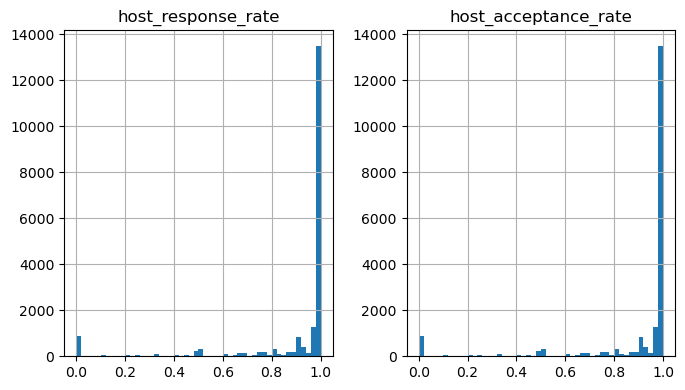

In [49]:
from matplotlib import pyplot as plt
listing[host_cols].hist(bins=50, figsize=(7, 4))
plt.tight_layout()
plt.show()

In [50]:
review_cols = [
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value'
]

listing[review_cols].describe()

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,24386.000000,24377.000000,24386.000000,24373.000000,24381.000000,24371.000000,24371.000000
mean,4.725517,4.764662,4.655944,4.835915,4.825407,4.744785,4.639542
std,0.450120,0.439058,0.506959,0.375445,0.412486,0.394611,0.491016
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.650000,4.710000,4.540000,4.820000,4.820000,4.660000,4.530000
50%,4.860000,4.900000,4.810000,4.950000,4.960000,4.860000,4.760000
75%,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.940000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


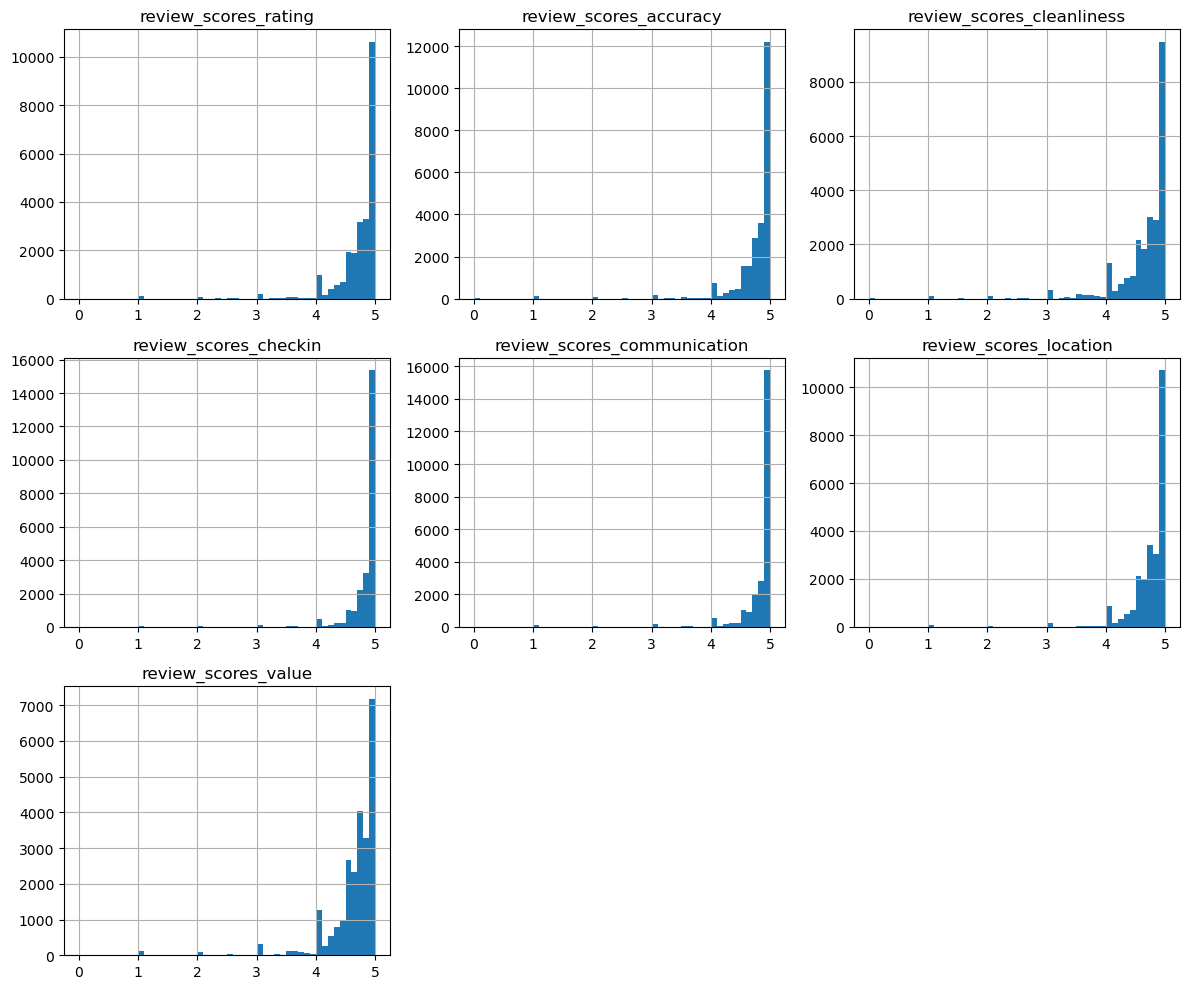

In [51]:
listing[review_cols].hist(bins=50, figsize=(12, 10))
plt.tight_layout()
plt.show()

In [52]:
#mean substitution
for col in host_cols:
    listing[col] = listing[col].fillna(listing[col].mean())

In [53]:
#mean substitution
for col in review_cols:
    listing[col] = listing[col].fillna(listing[col].mean())

#### c. Property attributes

* price: Numeric variables with highly skewed distributions --> replace missing price values using the mean, but only using values within the 3rd quartile (≤ 75th percentile).
* beds: Use mode
* bathrooms_number: Use mode

In [54]:
listing["price"].describe() #very highly skewed 

count    19888.000000
mean       575.915074
std       3996.366484
min         10.000000
25%         85.000000
50%        149.000000
75%        250.000000
max      50052.000000
Name: price, dtype: float64

In [55]:
# 1. Compute Q3 (75th percentile)
q3 = listing["price"].quantile(0.75)

# 2. Compute mean within Q3 (mean of lower 75% of prices)
mean_within_q3 = listing[listing["price"] <= q3]["price"].mean()

# 3. Replace missing values using this trimmed mean
listing["price"] = listing["price"].fillna(mean_within_q3)

In [56]:
bedroom_mode = listing["bedrooms"].mode() [0]
bedroom_mode

1.0

In [57]:
bed_mode = listing["beds"].mode() [0]
bed_mode

1.0

In [58]:
bathrooms_number_mode = listing["bathrooms_number"].mode() [0]
bathrooms_number_mode

1.0

In [59]:
listing.fillna({"bathrooms_number":bathrooms_number_mode, "bedrooms":bedroom_mode, "beds":bed_mode}, inplace = True)

In [60]:
listing.isnull().sum()

host_response_rate                                  0
host_acceptance_rate                                0
host_is_superhost                                   0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
latitude                                            0
longitude                                           0
accommodates                                        0
bedrooms                                            0
beds                                                0
price                                               0
minimum_nights                                      0
maximum_nights                                      0
minimum_minimum_nights                              0
maximum_minimum_nights                              0
minimum_maximum_nights                              0
maximum_maximum_nights                              0
minimum_nights_avg_ntm      

In [61]:
listing.shape

(34435, 57)

#### d. Behavior-related data

* estimated_revenue_l365d (>14,000 missing)
--> Missing means listing had zero bookings --> behavior signal --> replace by 0 instead of using mean or median

In [62]:
listing['estimated_revenue_l365d'].value_counts()

estimated_revenue_l365d
0.0         10581
7200.0         63
9000.0         57
10800.0        54
6000.0         49
            ...  
295035.0        1
45318.0         1
80256.0         1
49200.0         1
3534.0          1
Name: count, Length: 2382, dtype: int64

In [63]:
listing['estimated_revenue_l365d'] = listing['estimated_revenue_l365d'].fillna(0)

* reviews_per_month --> Missing means listing has no reviews --> better replace by 0

In [64]:
listing['reviews_per_month'].value_counts()

reviews_per_month
0.01     1291
0.02     1081
0.03      899
0.04      891
0.05      679
         ... 
10.32       1
5.24        1
6.15        1
10.16       1
9.00        1
Name: count, Length: 799, dtype: int64

In [65]:
listing["reviews_per_month"].describe()

count    24386.000000
mean         0.815943
std          1.917280
min          0.010000
25%          0.080000
50%          0.250000
75%          0.900000
max        122.760000
Name: reviews_per_month, dtype: float64

In [66]:
listing['reviews_per_month'] = listing['reviews_per_month'].fillna(0)

In [67]:
listing["host_response_time_score"].value_counts()

host_response_time_score
4.0    11318
3.0     4944
2.0     2052
1.0     1612
Name: count, dtype: int64

In Airbnb, missing response-time metrics typically indicate hosts who have not previously responded or are inactive. Therefore, missing values were imputed with the lowest response-time score (1), representing the slowest response behavior. This approach preserves business meaning and avoids overestimating host responsiveness.

In [68]:
listing["host_response_time_score"] = listing["host_response_time_score"].fillna(1.0)

In [69]:
listing.isnull().sum()

host_response_rate                                  0
host_acceptance_rate                                0
host_is_superhost                                   0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
latitude                                            0
longitude                                           0
accommodates                                        0
bedrooms                                            0
beds                                                0
price                                               0
minimum_nights                                      0
maximum_nights                                      0
minimum_minimum_nights                              0
maximum_minimum_nights                              0
minimum_maximum_nights                              0
maximum_maximum_nights                              0
minimum_nights_avg_ntm      

In [70]:
listing["minimum_minimum_nights"].describe()

count    34435.000000
mean        28.440540
std         29.322005
min          1.000000
25%         30.000000
50%         30.000000
75%         30.000000
max       1124.000000
Name: minimum_minimum_nights, dtype: float64

In [71]:
listing["maximum_minimum_nights"].describe()

count    34435.000000
mean        29.925483
std         38.087686
min          1.000000
25%         30.000000
50%         30.000000
75%         30.000000
max       1124.000000
Name: maximum_minimum_nights, dtype: float64

In [72]:
listing["minimum_maximum_nights"].describe()

count    3.443500e+04
mean     3.124501e+05
std      2.587554e+07
min      1.000000e+00
25%      2.000000e+02
50%      3.650000e+02
75%      1.125000e+03
max      2.147484e+09
Name: minimum_maximum_nights, dtype: float64

In [73]:
listing["maximum_maximum_nights"].describe()

count    3.443500e+04
mean     9.984749e+05
std      4.628018e+07
min      1.000000e+00
25%      3.650000e+02
50%      3.650000e+02
75%      1.125000e+03
max      2.147484e+09
Name: maximum_maximum_nights, dtype: float64

In [74]:
listing.dropna(subset = ["minimum_minimum_nights", "maximum_minimum_nights", "minimum_maximum_nights", "maximum_maximum_nights"], inplace = True)

In [75]:
listing.isnull().sum()

host_response_rate                                  0
host_acceptance_rate                                0
host_is_superhost                                   0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
latitude                                            0
longitude                                           0
accommodates                                        0
bedrooms                                            0
beds                                                0
price                                               0
minimum_nights                                      0
maximum_nights                                      0
minimum_minimum_nights                              0
maximum_minimum_nights                              0
minimum_maximum_nights                              0
maximum_maximum_nights                              0
minimum_nights_avg_ntm      

#### e. Review recency variables (days_since_first_rv, days_since_last_rv) --> replace by meaningful value

In [76]:
listing["days_since_first_rv"].describe()

count    24386.000000
mean      1933.749077
std       1258.243738
min          1.000000
25%        890.000000
50%       1656.000000
75%       2950.000000
max       5974.000000
Name: days_since_first_rv, dtype: float64

In [77]:
listing["days_since_last_rv"].describe()

count    24386.000000
mean      1012.605347
std       1132.528451
min          0.000000
25%         63.000000
50%        622.000000
75%       2014.750000
max       5257.000000
Name: days_since_last_rv, dtype: float64

NOTE: days_since_first_rv, days_since_last_rv

--> Missing = listing never reviewed (not just simply mean that there are missing values) 

--> This is a strong negative signal --> replace by an extremly large value (9999)

In [78]:
listing['days_since_first_rv'] = listing['days_since_first_rv'].fillna(9999)
listing['days_since_last_rv'] = listing['days_since_last_rv'].fillna(9999)

### *Final check

In [79]:
listing.isnull().sum()

host_response_rate                              0
host_acceptance_rate                            0
host_is_superhost                               0
host_total_listings_count                       0
host_has_profile_pic                            0
host_identity_verified                          0
latitude                                        0
longitude                                       0
accommodates                                    0
bedrooms                                        0
beds                                            0
price                                           0
minimum_nights                                  0
maximum_nights                                  0
minimum_minimum_nights                          0
maximum_minimum_nights                          0
minimum_maximum_nights                          0
maximum_maximum_nights                          0
minimum_nights_avg_ntm                          0
maximum_nights_avg_ntm                          0


## 2. Splitting dataset and Scaling

### 2.1 Arrange the columns

In [80]:
cols = listing.columns.tolist()
cols

['host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_total_listings_count',
 'host_has_profile_pic',
 'host_identity_verified',
 'latitude',
 'longitude',
 'accommodates',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'has_availability',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'instant_bookable',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_home

In [81]:
listing.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,bedrooms,...,days_since_last_rv,bathrooms_number,host_response_time_score,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,1.00000,1.00000,1.0,3.0,1.0,1.0,40.74698,-73.91763,1,1.0,...,57.0,1.0,3.0,0,0,1,0,0,1,0
1,0.89331,0.89331,0.0,1.0,1.0,1.0,40.72314,-73.99323,2,1.0,...,9999.0,1.0,1.0,0,1,0,0,0,1,0
2,0.89331,0.89331,0.0,1.0,1.0,1.0,40.64607,-74.00552,1,1.0,...,2083.0,1.0,1.0,1,0,0,0,0,1,0
3,0.89331,0.89331,0.0,3.0,1.0,1.0,40.68370,-73.96115,1,1.0,...,2041.0,1.0,1.0,1,0,0,0,0,0,0
4,0.90000,0.90000,1.0,16.0,1.0,1.0,40.72147,-73.98270,1,1.0,...,396.0,2.0,2.0,0,1,0,0,0,1,0


In [82]:
listing.shape

(34435, 57)

In [83]:
listing.columns.get_loc("latitude")

6

In [84]:
listing.columns.get_loc("neighbourhood_group_Brooklyn")

50

In [85]:
cols1 = [cols[2]] + cols[0:2] + cols[3:6] + cols[8:50] + cols[54:] + cols[50:54] + cols[6:8]
print(cols1)

['host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'accommodates', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_ho

In [86]:
listing1 = listing[cols1]
listing1.shape

(34435, 57)

In [87]:
y = listing1.iloc[:, 0] #host_is_super_host
x = listing1.iloc[:,1:51] #all other columns

In [88]:
y.name

'host_is_superhost'

In [89]:
x.columns

Index(['host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'accommodates', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'calculated_host_listings_count',
       'calculated_host_li

In [90]:
x.shape

(34435, 50)

### 2.2. Splitting to train set and test set

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=0) 

### 2.3. Data resampling (only the training set)

In [93]:
from sklearn.utils import resample

In [94]:
y_train.value_counts()

host_is_superhost
0.0    19112
1.0     4992
Name: count, dtype: int64

In [95]:
train0 = x_train[y_train == 0].copy() #non-superhost

In [96]:
train1 = x_train[y_train == 1].copy() #superhost

In [97]:
train0_downsample = resample(train0, replace=True, n_samples=len(train1), random_state=0) #downsample majority class

In [98]:
x_train_resampled = pd.concat([train1, train0_downsample], axis=0) #concatenate back x_trained

In [99]:
#build matching y for the resampled x
y0 = y_train[y_train == 0]
y1 = y_train[y_train == 1]
y0_downsample = resample(y0, replace=True, n_samples=len(y1), random_state=0)
y_train_resampled = pd.concat([y1, y0_downsample], axis=0)

In [100]:
y_train_resampled.value_counts()

host_is_superhost
1.0    4992
0.0    4992
Name: count, dtype: int64

### 2.4. Scaling the data (fit only the training set)

In [101]:
from sklearn.preprocessing import StandardScaler #scaled data will be used for SVM, KNN, MLP

In [102]:
scaler = StandardScaler() #build scaler object

In [103]:
scaler_model = scaler.fit(x_train_resampled) #fit on the training data only

In [104]:
x_train_scaled = scaler_model.transform(x_train_resampled) #transform training set
x_test_scaled = scaler_model.transform(x_test) #transform test set

# C. Models

## *Summary of variables after preprocessing

In [105]:
#after train_test_split
x_train, x_test, y_test, y_train

(       host_response_rate  host_acceptance_rate  host_total_listings_count  \
 34725             0.99000               0.99000                        2.0   
 33949             1.00000               1.00000                       21.0   
 20365             0.99000               0.99000                       13.0   
 16799             0.89331               0.89331                      107.0   
 19546             1.00000               1.00000                       29.0   
 ...                   ...                   ...                        ...   
 21253             1.00000               1.00000                        1.0   
 33521             1.00000               1.00000                        1.0   
 31577             1.00000               1.00000                       10.0   
 21757             1.00000               1.00000                       16.0   
 2754              0.89331               0.89331                        4.0   
 
        host_has_profile_pic  host_identity_verifi

In [106]:
#after resampling only training set
x_train_resampled, y_train_resampled

(       host_response_rate  host_acceptance_rate  host_total_listings_count  \
 33949             1.00000               1.00000                       21.0   
 20365             0.99000               0.99000                       13.0   
 12971             0.96000               0.96000                        1.0   
 29981             0.99000               0.99000                       25.0   
 31186             1.00000               1.00000                        1.0   
 ...                   ...                   ...                        ...   
 4086              1.00000               1.00000                       19.0   
 16493             1.00000               1.00000                        3.0   
 12033             0.89331               0.89331                        3.0   
 20327             0.89331               0.89331                        3.0   
 20057             0.89331               0.89331                        1.0   
 
        host_has_profile_pic  host_identity_verifi

In [107]:
#after scaling (fit on x_train_resampled only)
x_train_scaled, x_test_scaled #scaled x will be used for SVM, KNN, MLP

(array([[ 0.49052804,  0.49052804, -0.17355504, ..., -0.07710113,
         -0.90603585, -0.09211324],
        [ 0.42870367,  0.42870367, -0.18465903, ..., -0.07710113,
         -0.90603585, -0.09211324],
        [ 0.24323056,  0.24323056, -0.20131502, ..., -0.07710113,
          1.10370908, -0.09211324],
        ...,
        [-0.16907772, -0.16907772, -0.19853902, ..., -0.07710113,
          1.10370908, -0.09211324],
        [-0.16907772, -0.16907772, -0.19853902, ..., -0.07710113,
         -0.90603585, -0.09211324],
        [-0.16907772, -0.16907772, -0.20131502, ..., -0.07710113,
         -0.90603585, -0.09211324]]),
 array([[-0.16907772, -0.16907772, -0.20131502, ..., -0.07710113,
         -0.90603585, -0.09211324],
        [ 0.11958183,  0.11958183, -0.19298702, ..., -0.07710113,
          1.10370908, -0.09211324],
        [-0.16907772, -0.16907772, -0.19992702, ..., -0.07710113,
         -0.90603585, -0.09211324],
        ...,
        [ 0.49052804,  0.49052804, -0.15134706, ..., -

## *Models

In [108]:
from sklearn.model_selection import cross_val_score

In [109]:
import numpy as np

In [110]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

## 1. Decision Tree (unscaled)

In [111]:
depths = range(1, 16)  # test max_depth from 1 to 15
cv_scores = []

for d in depths:
    dt = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=0)
    scores = cross_val_score(dt, x_train_resampled, y_train_resampled, cv=5)
    cv_scores.append(np.mean(scores))

# Print results
for d, score in zip(depths, cv_scores):
    print("Depth:", d, " CV Score:", score)

Depth: 1  CV Score: 0.7681299002612135
Depth: 2  CV Score: 0.8001818860555362
Depth: 3  CV Score: 0.809996708489588
Depth: 4  CV Score: 0.8139027679796248
Depth: 5  CV Score: 0.8272238016343152
Depth: 6  CV Score: 0.8412458366909081
Depth: 7  CV Score: 0.8452529495646275
Depth: 8  CV Score: 0.8485580073517088
Depth: 9  CV Score: 0.8556686231752438
Depth: 10  CV Score: 0.8577725807147594
Depth: 11  CV Score: 0.8602762359972825
Depth: 12  CV Score: 0.8609778395047482
Depth: 13  CV Score: 0.8616785398538689
Depth: 14  CV Score: 0.8584736322921256
Depth: 15  CV Score: 0.8631819974450654


In [112]:
dt = DecisionTreeClassifier(criterion = "entropy", max_depth = 13, random_state = 0) 
dt_score = cross_val_score(dt, x_train_resampled, y_train_resampled, cv=5)
print("Decision Tree CV Score:", np.mean(dt_score), "(", np.std(dt_score), ")")

Decision Tree CV Score: 0.8616785398538689 ( 0.012338406952938592 )


In [113]:
#Fit the model on the resampled train_set
dt_model = dt.fit(x_train_resampled, y_train_resampled)
y_pred_dt = dt_model.predict(x_test)

In [114]:
from sklearn import metrics

In [115]:
dt_accuracy = metrics.accuracy_score(y_test, y_pred_dt)
dt_accuracy

0.8244119639918691

In [116]:
metrics.confusion_matrix(y_test,y_pred_dt)

array([[6508, 1632],
       [ 182, 2009]], dtype=int64)

In [117]:
from sklearn.tree import plot_tree

In [118]:
from matplotlib import pyplot as plt

In [119]:
x_train.head()

,host_response_rate,host_acceptance_rate,host_total_listings_count,host_has_profile_pic,host_identity_verified,accommodates,bedrooms,beds,price,minimum_nights,...,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,days_since_first_rv,days_since_last_rv,bathrooms_number,host_response_time_score,room_type_Hotel room,room_type_Private room,room_type_Shared room
34725,0.99000,0.99000,2.0,1.0,1.0,4,1.0,2.0,214.000000,1,...,0,4.80,23,49.0,2.0,1.0,4.0,0,1,0
33949,1.00000,1.00000,21.0,1.0,1.0,4,1.0,1.0,356.000000,3,...,0,0.00,31,9999.0,9999.0,1.0,4.0,0,0,0
20365,0.99000,0.99000,13.0,1.0,1.0,6,0.0,4.0,331.000000,1,...,0,2.41,38,1055.0,65.0,1.0,4.0,0,0,0
16799,0.89331,0.89331,107.0,1.0,1.0,2,1.0,1.0,122.832489,1,...,0,0.94,19,1698.0,956.0,1.0,1.0,0,1,0
19546,1.00000,1.00000,29.0,1.0,1.0,2,1.0,1.0,72.000000,30,...,0,0.00,5,9999.0,9999.0,1.0,4.0,0,1,0


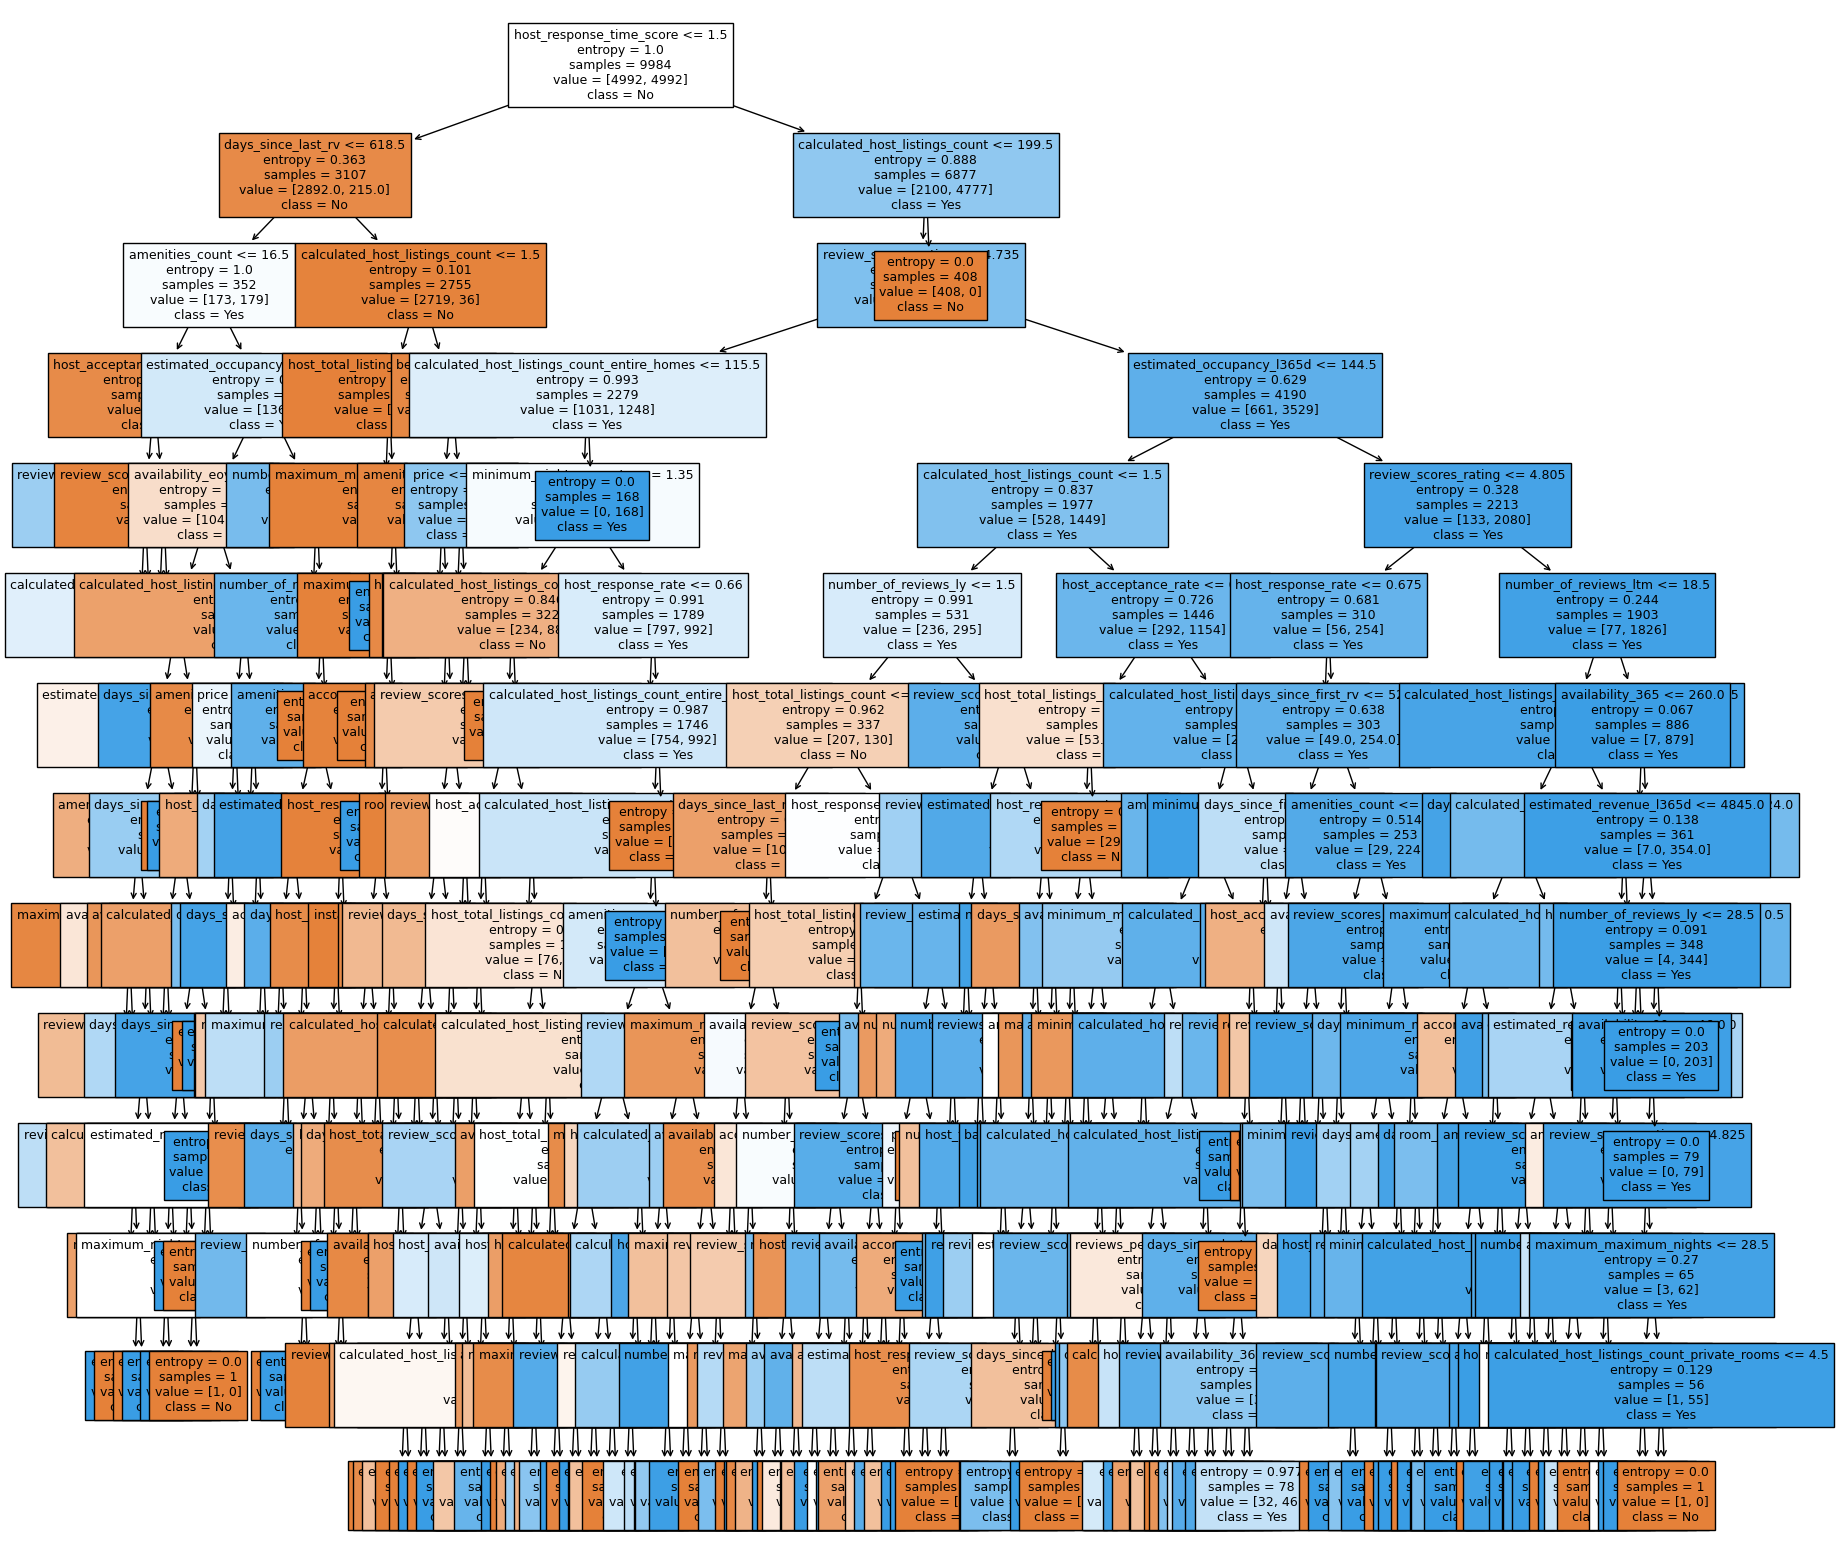

In [120]:
plt.figure(figsize=(20,20))
plot_tree(dt_model, feature_names=x.columns, fontsize = 9, class_names=['No','Yes'], filled=True)
plt.show()

## 2. Random Forest (unscaled)

In [121]:
nums = [10, 20, 50, 100, 200, 300, 500]   # candidate number of trees
results = []

In [122]:
for n in nums:
    rf_n = RandomForestClassifier(n_estimators = n, random_state = 0)
    rf_scores = cross_val_score(rf_n, x_train_resampled, y_train_resampled,
                             cv = 5, scoring = "accuracy") #choose metric: "accuracy"
    mean_score_rf = np.mean(rf_scores)
    results.append(mean_score_rf)
    print(n, "trees → mean accuracy:", round(mean_score_rf, 4))

10 trees → mean accuracy: 0.8862
20 trees → mean accuracy: 0.8946
50 trees → mean accuracy: 0.8982
100 trees → mean accuracy: 0.9027
200 trees → mean accuracy: 0.9024
300 trees → mean accuracy: 0.9034
500 trees → mean accuracy: 0.9033


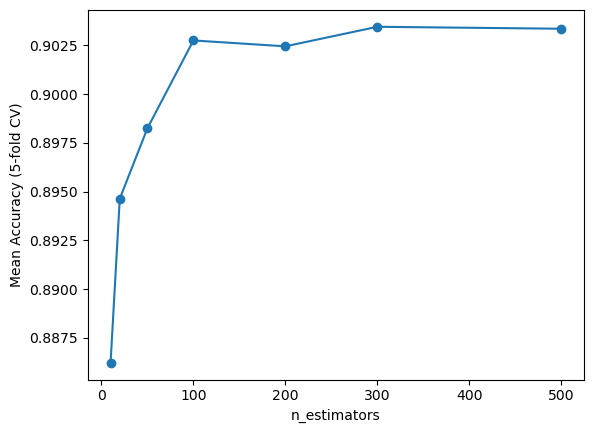

In [123]:
plt.plot(nums, results, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Mean Accuracy (5-fold CV)")
plt.show()

In [124]:
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model = rf.fit(x_train_resampled, y_train_resampled)

In [125]:
y_pred_rf = rf_model.predict(x_test)

In [126]:
rf_accuracy = metrics.accuracy_score(y_test, y_pred_rf)
rf_accuracy

0.858387377794986

In [127]:
#feature importance
fi = rf_model.feature_importances_
fi

array([0.05483075, 0.06786725, 0.03683986, 0.00079968, 0.00271078,
       0.01005644, 0.00640283, 0.00827658, 0.0206891 , 0.00374785,
       0.01075719, 0.00429287, 0.00461595, 0.01013861, 0.0077462 ,
       0.006176  , 0.00865108, 0.00076172, 0.00923492, 0.01211714,
       0.01447232, 0.03075376, 0.01417757, 0.0337003 , 0.00310316,
       0.02058356, 0.03280935, 0.04462175, 0.02768718, 0.02594812,
       0.01841248, 0.02107174, 0.01092206, 0.02250003, 0.01050714,
       0.01876107, 0.00431079, 0.04987945, 0.02607176, 0.02206686,
       0.00203373, 0.02222237, 0.04473633, 0.01658694, 0.08049292,
       0.0053979 , 0.08542133, 0.00100344, 0.00281575, 0.00021607])

In [128]:
x_train_resampled.columns.tolist()

['host_response_rate',
 'host_acceptance_rate',
 'host_total_listings_count',
 'host_has_profile_pic',
 'host_identity_verified',
 'accommodates',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'has_availability',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'instant_bookable',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_room

In [129]:
pd.DataFrame({"Variable": x_train_resampled.columns.tolist(), "Feature Importance": fi })

,Variable,Feature Importance
0,host_response_rate,0.054831
1,host_acceptance_rate,0.067867
2,host_total_listings_count,0.036840
3,host_has_profile_pic,0.000800
4,host_identity_verified,0.002711
5,accommodates,0.010056
6,bedrooms,0.006403
7,beds,0.008277
8,price,0.020689
9,minimum_nights,0.003748


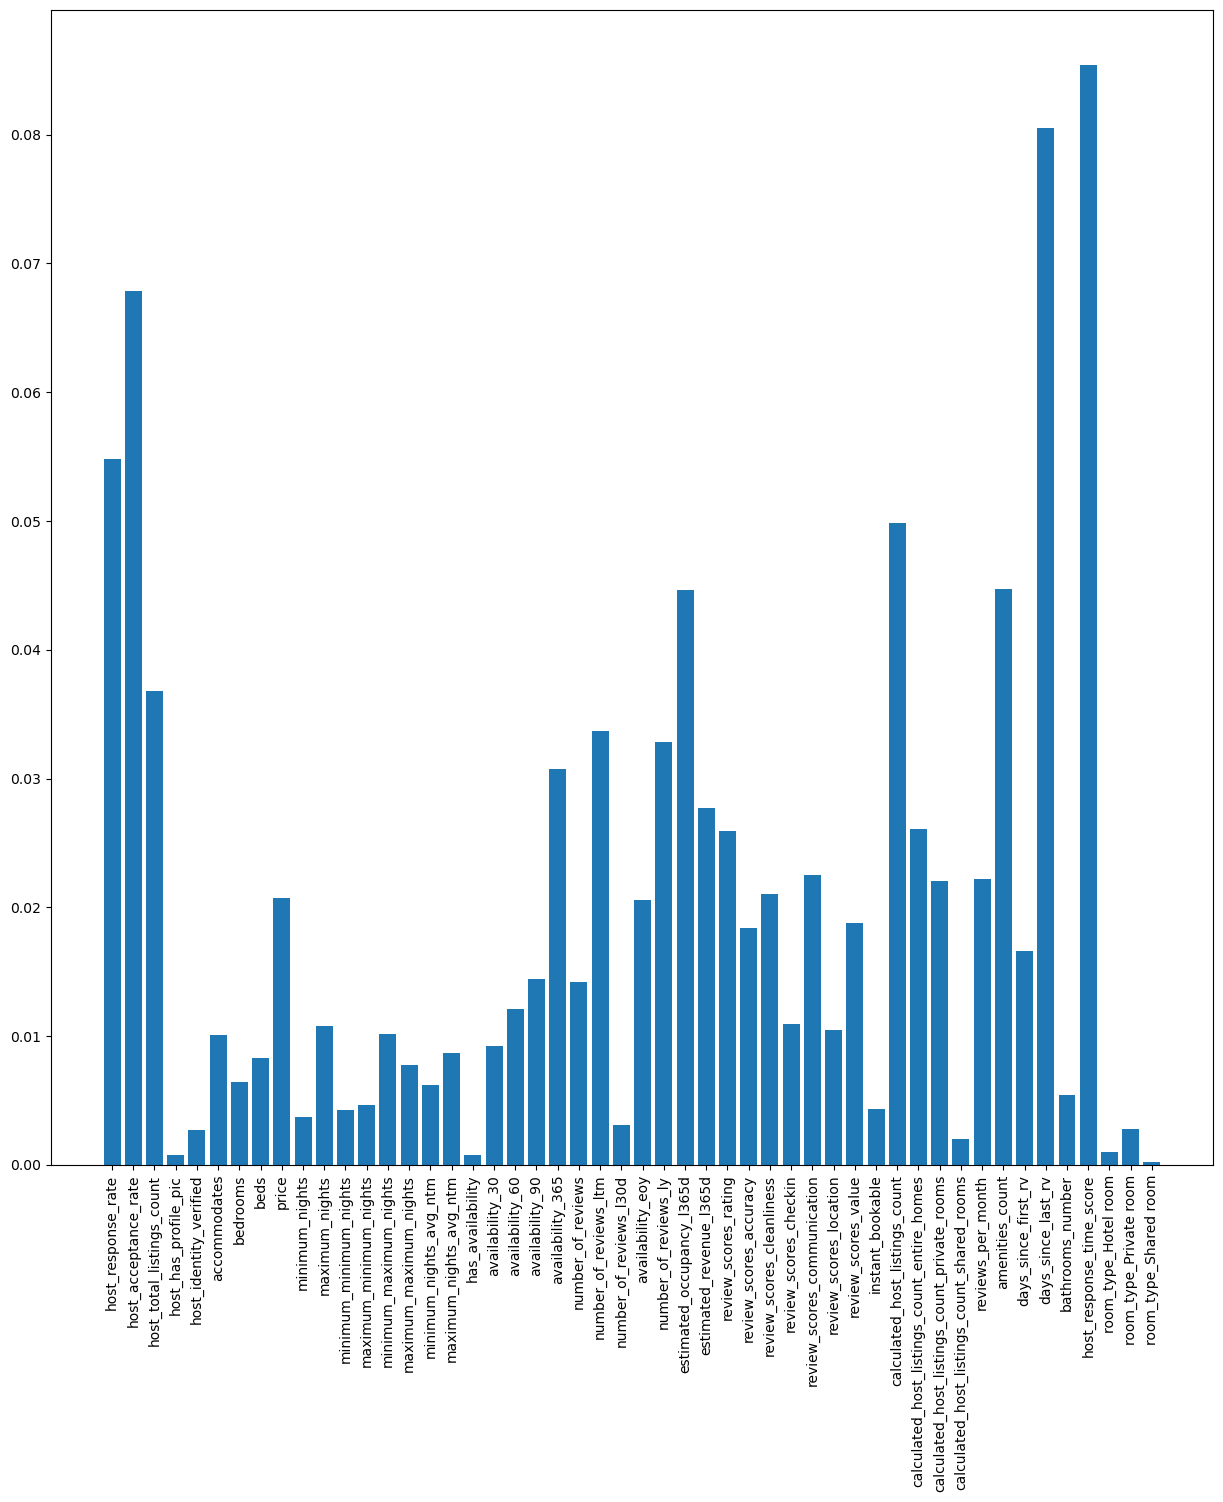

In [130]:
plt.figure(figsize = (15,15))
plt.bar(x_train_resampled.columns.tolist(), fi)
plt.xticks(rotation = 90) #Rotate the labels on the x-axis 
plt.show()

## 3. ANN (scaled)

### single hidden layer

In [131]:
nums = list(range(1, 31))
nums

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30]

In [132]:
for n in nums:
    mlp_n = MLPClassifier(activation="relu", hidden_layer_sizes=(n), max_iter=2000, random_state=0)
    scores = cross_val_score(mlp_n, x_train_scaled, y_train_resampled, cv=5)
    mean = np.mean(scores)
    print(str(n) + ": " + str(mean))

1: 0.8275243024857929
2: 0.8308304139576098
3: 0.8342349696890026
4: 0.8446520482125995
5: 0.8481577075031386
6: 0.8534660708497617
7: 0.8508611113062379
8: 0.8558701780125098
9: 0.8589748851734516
10: 0.8521638670430495
11: 0.8536666723532191
12: 0.8590744332932264
13: 0.8548690771628383
14: 0.8620797930362478
15: 0.8567709279349887
16: 0.8598755347450033
17: 0.8591761891333995
18: 0.8589744335942792
19: 0.8574726317933814
20: 0.8635817955389999
21: 0.8563704273845639
22: 0.8611783908327422
23: 0.8592758376041015
24: 0.8599767386550768
25: 0.8560704282877222
26: 0.8561697255301791
27: 0.8570708266809032
28: 0.8578729818174156
29: 0.8561702774602786
30: 0.8586742337955832


In [133]:
mlp = MLPClassifier(activation="relu", hidden_layer_sizes=(6), max_iter=2000, random_state=0)

In [134]:
mlp_model = mlp.fit(x_train_scaled, y_train_resampled)

In [135]:
y_pred_mlp = mlp_model.predict(x_test_scaled)

In [136]:
metrics.accuracy_score(y_test, y_pred_mlp)

0.8336075888103766

cv score: 0.8534660708497617 

### 3 hidden layers

In [137]:
import itertools

In [138]:
a = b = c = range(1, 5)

In [139]:
abc = list(itertools.product(a, b, c))
print(abc)

[(1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 1, 4), (1, 2, 1), (1, 2, 2), (1, 2, 3), (1, 2, 4), (1, 3, 1), (1, 3, 2), (1, 3, 3), (1, 3, 4), (1, 4, 1), (1, 4, 2), (1, 4, 3), (1, 4, 4), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 1, 4), (2, 2, 1), (2, 2, 2), (2, 2, 3), (2, 2, 4), (2, 3, 1), (2, 3, 2), (2, 3, 3), (2, 3, 4), (2, 4, 1), (2, 4, 2), (2, 4, 3), (2, 4, 4), (3, 1, 1), (3, 1, 2), (3, 1, 3), (3, 1, 4), (3, 2, 1), (3, 2, 2), (3, 2, 3), (3, 2, 4), (3, 3, 1), (3, 3, 2), (3, 3, 3), (3, 3, 4), (3, 4, 1), (3, 4, 2), (3, 4, 3), (3, 4, 4), (4, 1, 1), (4, 1, 2), (4, 1, 3), (4, 1, 4), (4, 2, 1), (4, 2, 2), (4, 2, 3), (4, 2, 4), (4, 3, 1), (4, 3, 2), (4, 3, 3), (4, 3, 4), (4, 4, 1), (4, 4, 2), (4, 4, 3), (4, 4, 4)]


In [140]:
for n in abc:
    mlp_n = MLPClassifier(activation="relu", hidden_layer_sizes=n, max_iter=2000, random_state=0)
    scores = cross_val_score(mlp_n, x_train_scaled, y_train_resampled, cv=5)
    mean = np.mean(scores)
    print(str(n) + ": " + str(mean))

(1, 1, 1): 0.5
(1, 1, 2): 0.827825004039125
(1, 1, 3): 0.8304291105997674
(1, 1, 4): 0.5
(1, 2, 1): 0.8296276077442817
(1, 2, 2): 0.5
(1, 2, 3): 0.8230176426965098
(1, 2, 4): 0.8231183950274108
(1, 3, 1): 0.5
(1, 3, 2): 0.5
(1, 3, 3): 0.8267235522622611
(1, 3, 4): 0.8264233022881016
(1, 4, 1): 0.5
(1, 4, 2): 0.8246205982320175
(1, 4, 3): 0.8258224009360735
(1, 4, 4): 0.8288266568188958
(2, 1, 1): 0.8265232518115851
(2, 1, 2): 0.8322319651822422
(2, 1, 3): 0.8423480912751893
(2, 1, 4): 0.844451446709142
(2, 2, 1): 0.8308296613256558
(2, 2, 2): 0.8405454875700326
(2, 2, 3): 0.8273248048425342
(2, 2, 4): 0.8343353707916584
(2, 3, 1): 0.8299280082448324
(2, 3, 2): 0.8286266072455376
(2, 3, 3): 0.8286269082983193
(2, 3, 4): 0.8322325672878055
(2, 4, 1): 0.8346357211167452
(2, 4, 2): 0.8348356703391762
(2, 4, 3): 0.8373405298328255
(2, 4, 4): 0.8307304644341261
(3, 1, 1): 0.8432497443560131
(3, 1, 2): 0.8369393770013739
(3, 1, 3): 0.837439977601673
(3, 1, 4): 0.8291267562666647
(3, 2, 1): 0.

In [141]:
mlp_3 = MLPClassifier(activation="relu", hidden_layer_sizes=(4, 3, 4), max_iter=2000, random_state=0)

In [142]:
mlp_3_model = mlp_3.fit(x_train_scaled, y_train_resampled)

In [143]:
y_pred_mlp_3 = mlp_3_model.predict(x_test_scaled)

In [144]:
metrics.accuracy_score(y_test, y_pred_mlp_3)

0.830994095440906

cv score: 0.8577730824693954

## 4. SVM (scaled)

### Linear SVM

In [145]:
lsvm = SVC(kernel = "linear", C = 1)
scores = cross_val_score(lsvm, x_train_scaled, y_train_resampled, cv=5)
np.mean(scores)

0.8285265573711268

In [146]:
lsvm_model = lsvm.fit(x_train_scaled, y_train_resampled)

In [147]:
y_pred_lsvm = lsvm_model.predict(x_test_scaled)

In [148]:
metrics.accuracy_score(y_test, y_pred_lsvm)

0.7801761688123124

cv score: 0.8285265573711268

### Non-linear SVM

In [149]:
svc = SVC(kernel = "rbf", C = 1, gamma = 1)
scores = cross_val_score(svc,  x_train_scaled, y_train_resampled, cv=5)
np.mean(scores)

0.7441915879831771

In [150]:
svc_model = svc.fit(x_train_scaled, y_train_resampled)

In [151]:
y_pred_svc = svc_model.predict(x_test_scaled)

In [152]:
metrics.accuracy_score(y_test, y_pred_svc)

0.5154389700900204

cv score: 0.7441915879831771

## 5. KNN (scaled)

In [153]:
from sklearn.model_selection import GridSearchCV

param_grid = {"n_neighbors": range(1, 11)}  

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(x_train_scaled, y_train_resampled)

print(grid.best_params_)
print(grid.best_score_)

{'n_neighbors': 1}
0.8507613624846087


In [154]:
knn = KNeighborsClassifier(n_neighbors=1)

In [155]:
knn_model = knn.fit(x_train_scaled, y_train_resampled)

In [156]:
y_pred = knn_model.predict(x_test_scaled)

In [157]:
from sklearn import metrics
knn_accuracy = metrics.accuracy_score(y_test, y_pred)
knn_accuracy

0.812409253702449

In [158]:
knn_scores = cross_val_score(knn_model, x_train_scaled, y_train_resampled, cv=5)
np.mean(knn_scores)

0.8507613624846087

## 6. Naive Bayes (unscaled)

In [159]:
from sklearn.naive_bayes import GaussianNB

In [160]:
nb = GaussianNB()

In [161]:
nb_model = nb.fit(x_train_resampled, y_train_resampled)

In [162]:
nb_y_pred = nb_model.predict(x_test)

In [163]:
nb_accuracy = metrics.accuracy_score(y_test, nb_y_pred)
nb_accuracy

0.2174039299196593

In [164]:
nb_scores = cross_val_score(nb_model, x_train_resampled, y_train_resampled, cv=5)
np.mean(nb_scores)

0.5037060600921422

# D. Final model + Predict

## A. Data

In [165]:
file_path = r"E:\BA2\Team Prj\test_f25.xlsx"
test = pd.read_excel(file_path)
test.head()

,No,host_is_superhost,host_response_time,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,property_type,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1,NaN,within an hour,100%,78%,1.0,1.0,f,f,Entire rental unit,...,5.00,5.00,5.00,5.00,f,1,1,0,0,0.45
1,2,NaN,NaN,NaN,NaN,1.0,1.0,t,t,Entire rental unit,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
2,3,NaN,within a day,50%,50%,20.0,22.0,t,t,Entire rental unit,...,4.77,4.88,4.77,4.73,f,18,4,14,0,0.73
3,4,NaN,within an hour,100%,100%,26.0,26.0,t,t,Entire condo,...,4.94,4.99,4.66,4.89,t,10,10,0,0,3.80
4,5,NaN,within an hour,100%,100%,53.0,53.0,t,t,Entire rental unit,...,4.93,4.95,4.83,4.86,t,37,36,0,0,2.07


In [166]:
test.columns

Index(['No', 'host_is_superhost', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'calendar_last_scraped', 'number_of_reviews',
       'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy',
       'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'first_review', 'last_review',
       'review_scores_rating', 'review_scores_acc

In [167]:
test.shape

(130, 55)

## B. Preproccesing

### 1. Data cleansing and transformation

Text data to be transformed:
1. amenities: extract amenities_count
2. calendar_updated - first_review (or last_review) = days_since_first review (or days_since_last_review)
3. bathrooms_text to numerical variables, and drop the bathrooms column due to larger number of missing values compared to bathrooms_text

#### 1.2. Data transformations

##### a. Convert 'amenities' to 'amenities_count'

This will be better instead of dropping this column out of our dataset because
* The number of amenities strongly reflects listing quality --> affects guest satisfaction --> affects review scores --> affects chances of being Superhost.

In [168]:
test["amenities"]

0      ["Wifi", "Washer", "Kitchen", "First aid kit",...
1      ["Hangers", "Dedicated workspace", "Kitchen", ...
2      ["Hangers", "Dedicated workspace", "Kitchen", ...
3      ["Hangers", "Kitchen", "Park view", "Wine glas...
4      ["Hangers", "Kitchen", "Oven", "Outdoor furnit...
                             ...                        
125    ["Iron", "Trash compactor", "Pack \u2019n play...
126    ["Iron", "Dishwasher", "Dining table", "TV", "...
127    ["Iron", "Laundromat nearby", "Luggage dropoff...
128    ["Iron", "Private entrance", "Smoke alarm", "F...
129    ["Iron", "Pack \u2019n play/Travel crib", "Cof...
Name: amenities, Length: 130, dtype: object

In [169]:
import ast
import pandas as pd

def count_amenities(x):
    # Case 1: already a Python list
    if isinstance(x, list):
        return len(x)
    
    # Case 2: it's a string
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return 0
        try:
            # Try to interpret it as a Python-style list string
            items = ast.literal_eval(s)
            return len(items)
        except Exception:
            # Fallback: treat it as a comma-separated string
            return len([a for a in s.split(',') if a.strip() != ""])
    
    # Case 3: NaN or anything else
    return 0

test['amenities_count'] = test['amenities'].apply(count_amenities)

In [170]:
test["amenities_count"].head()

0     8
1    40
2    34
3    48
4    26
Name: amenities_count, dtype: int64

In [171]:
test.drop(columns=['amenities'], inplace=True)

##### b. Convert data variables --> numeric features

##### *review recency 

* last_scraped - first_review = how long it has been since the host got their first review
  
--> Transform to 'review_active_years'

* last_scraped - last_review = how long since their most recent review
  
--> Transform to 'days_since_last_review

These can be strong predictors because:
* Superhosts must have consistent bookings
* If last review is long ago → low activity → less likely Superhost

In [172]:
#convert to datetime
test["first_review"] = pd.to_datetime(test["first_review"], errors = 'coerce')
test["last_review"] = pd.to_datetime(test["last_review"], errors = 'coerce')
test["calendar_last_scraped"] = pd.to_datetime(test["calendar_last_scraped"], errors = 'coerce')

In [173]:
#days since first review
test["days_since_first_rv"] = (test['calendar_last_scraped'] - test['first_review']).dt.days
#days since last review
test['days_since_last_rv'] = (test['calendar_last_scraped'] - test['last_review']).dt.days

In [174]:
#drop the original date columns
test.drop(columns=["calendar_last_scraped", "first_review", "last_review"], inplace=True)

In [175]:
test["days_since_first_rv"].describe()

count     100.000000
mean     1477.950000
std      1260.858489
min         3.000000
25%       376.000000
50%       994.000000
75%      2601.000000
max      4218.000000
Name: days_since_first_rv, dtype: float64

In [176]:
test["days_since_last_rv"].describe()

count     100.00000
mean      463.42000
std       857.09446
min         0.00000
25%        17.00000
50%        59.50000
75%       405.75000
max      3636.00000
Name: days_since_last_rv, dtype: float64

In [177]:
test.head()

,No,host_is_superhost,host_response_time,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,property_type,...,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,days_since_first_rv,days_since_last_rv
0,1,NaN,within an hour,100%,78%,1.0,1.0,f,f,Entire rental unit,...,5.00,f,1,1,0,0,0.45,8,267.0,41.0
1,2,NaN,NaN,NaN,NaN,1.0,1.0,t,t,Entire rental unit,...,NaN,f,1,1,0,0,NaN,40,NaN,NaN
2,3,NaN,within a day,50%,50%,20.0,22.0,t,t,Entire rental unit,...,4.73,f,18,4,14,0,0.73,34,2461.0,63.0
3,4,NaN,within an hour,100%,100%,26.0,26.0,t,t,Entire condo,...,4.89,t,10,10,0,0,3.80,48,1349.0,128.0
4,5,NaN,within an hour,100%,100%,53.0,53.0,t,t,Entire rental unit,...,4.86,t,37,36,0,0,2.07,26,2435.0,16.0


In [178]:
test.columns

Index(['No', 'host_is_superhost', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_listings_count',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       

##### d. Categorical variables

##### *Bathrooms vs. bathrooms_text

In [179]:
test["bathrooms"].value_counts() 

bathrooms
1.0    57
2.0    12
1.5     6
4.0     2
3.5     2
2.5     2
3.0     2
Name: count, dtype: int64

In [180]:
test["bathrooms_text"].value_counts() 
#transform to categorical variables, and drop the bathrooms column due to overlapping values

bathrooms_text
1 bath            72
2 baths           21
1 private bath    12
1.5 baths          8
1 shared bath      6
2.5 baths          4
3.5 baths          2
3 baths            2
4 baths            1
4 shared baths     1
2 shared baths     1
Name: count, dtype: int64

In [181]:
test.drop(columns = ["bathrooms"], inplace = True) #due to overlapping values

In [182]:
#transform bathrooms_text
test_mapping1 = {
    "1 bath": 1,  
    "2 baths": 2,
    "1 private bath": 1, 
    "1.5 baths": 1.5,     
    "1 shared bath": 1,
    "2.5 baths": 2.5,
    "3.5 baths": 3.5, 
    "3 baths": 3,        
    "4 baths": 4,           
    "4 shared baths": 4,   
    "2 shared baths": 2}  

In [183]:
test["bathrooms_text"] = test["bathrooms_text"].map(test_mapping1)

In [184]:
test["bathrooms_text"].value_counts()

bathrooms_text
1.0    90
2.0    22
1.5     8
2.5     4
4.0     2
3.5     2
3.0     2
Name: count, dtype: int64

In [185]:
test["bathrooms_number"] = test["bathrooms_text"]
test.drop(columns = ["bathrooms_text"], inplace = True) #already renamed bathrooms_text to bathrooms_number

##### *Ordinal encoding host_response_time

In [186]:
test["host_response_time"]

0      within an hour
1                 NaN
2        within a day
3      within an hour
4      within an hour
            ...      
125    within an hour
126    within an hour
127    within an hour
128               NaN
129    within an hour
Name: host_response_time, Length: 130, dtype: object

Ordinal encoding makes sense because response time is ordered:
* Fast = Good
* Slow = Bad

In [187]:
#Ordinal Encoding (fastest response = highest score)
test_mapping2 = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1
}

test['host_response_time_score'] = test['host_response_time'].map(test_mapping2)

#Drop the original host_response_time column
test.drop(columns = ["host_response_time"], inplace = True)
test['host_response_time_score'].describe()

count    96.00000
mean      3.50000
std       0.90612
min       1.00000
25%       3.00000
50%       4.00000
75%       4.00000
max       4.00000
Name: host_response_time_score, dtype: float64

##### *Convert t/f to binary variables (1/0): super_host, instant_bookable, has_availability, host_has_picture_pic, host_identity_verified

In [188]:
test["instant_bookable"].value_counts()

instant_bookable
f    87
t    43
Name: count, dtype: int64

In [189]:
test["has_availability"].value_counts()

has_availability
t    124
Name: count, dtype: int64

In [190]:
test["has_availability"].isnull().sum()

6

In [191]:
test["host_has_profile_pic"].value_counts()

host_has_profile_pic
t    123
f      6
Name: count, dtype: int64

In [192]:
test["host_identity_verified"].value_counts()

host_identity_verified
t    123
f      6
Name: count, dtype: int64

In [193]:
test_mapping2 = {"t":1, "f":0}
test["instant_bookable"] = test["instant_bookable"].map(test_mapping2)
test["has_availability"] = test["has_availability"].map(test_mapping2).fillna(0) 
test["host_has_profile_pic"] = test["host_has_profile_pic"].map(test_mapping2)
test["host_identity_verified"] = test["host_identity_verified"].map(test_mapping2)

##### *Transfrom room_type to dummies

In [194]:
test["room_type"].value_counts()

room_type
Entire home/apt    101
Private room        28
Shared room          1
Name: count, dtype: int64

In [195]:
test["property_type"].value_counts() 

property_type
Entire rental unit                   66
Entire home                          15
Entire condo                         13
Private room in rental unit          13
Private room in home                  5
Room in hotel                         4
Entire townhouse                      3
Entire guest suite                    2
Private room in bed and breakfast     2
Entire serviced apartment             2
Shared room in bed and breakfast      1
Private room in loft                  1
Private room in condo                 1
Private room in villa                 1
Private room in hostel                1
Name: count, dtype: int64

In [196]:
test = pd.get_dummies(test, columns = ["room_type"], drop_first = True, dtype = int)

In [197]:
test.drop(columns = ["property_type", "No"], inplace = True) 
#decide to drop property column to align with our internal dataset

##### *Convert % variables to numeric: host_response rate, host_acceptance_rate

In [198]:
test['host_response_rate'] = (
    test['host_response_rate']
        .astype(str)          # convert all to string
        .str.replace('%', '') # remove %
        .replace('nan', None) # convert "nan" strings back to real NaN
        .astype(float)        # convert to float
)
test['host_response_rate'] = test['host_response_rate']

In [199]:
test['host_acceptance_rate'] = (
    test['host_acceptance_rate']
        .astype(str)          # convert all to string
        .str.replace('%', '') # remove %
        .replace('nan', None) # convert "nan" strings back to real NaN
        .astype(float)        # convert to float
)
test['host_acceptance_rate'] = test['host_acceptance_rate']

#### 1.3. Handle missing values

In [200]:
test.isnull().sum()

host_is_superhost                               130
host_response_rate                               34
host_acceptance_rate                             34
host_listings_count                               1
host_total_listings_count                         1
host_has_profile_pic                              1
host_identity_verified                            1
accommodates                                      0
bedrooms                                         12
beds                                             47
price                                            47
minimum_nights                                    0
maximum_nights                                    0
minimum_minimum_nights                            0
maximum_minimum_nights                            0
minimum_maximum_nights                            0
maximum_maximum_nights                            0
minimum_nights_avg_ntm                            0
maximum_nights_avg_ntm                            0
calendar_upd

##### a. Listwise  deletion

In [201]:
test.drop(columns = ["calendar_updated", "host_listings_count"], inplace = True) #useless columns, or columns with 0 values
test.isnull().sum()

host_is_superhost                               130
host_response_rate                               34
host_acceptance_rate                             34
host_total_listings_count                         1
host_has_profile_pic                              1
host_identity_verified                            1
accommodates                                      0
bedrooms                                         12
beds                                             47
price                                            47
minimum_nights                                    0
maximum_nights                                    0
minimum_minimum_nights                            0
maximum_minimum_nights                            0
minimum_maximum_nights                            0
maximum_maximum_nights                            0
minimum_nights_avg_ntm                            0
maximum_nights_avg_ntm                            0
has_availability                                  0
availability

##### b. Host-related & Review_scores_*

In [202]:
test.columns

Index(['host_is_superhost', 'host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'accommodates', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'calculated_host_listings_count',
     

In [203]:
host_cols = [
    'host_response_rate', 'host_acceptance_rate'
]

test[host_cols].describe()

,host_response_rate,host_acceptance_rate
count,96.000000,96.000000
mean,91.927083,83.916667
std,22.450528,29.346090
min,0.000000,0.000000
25%,98.750000,87.750000
50%,100.000000,98.000000
75%,100.000000,100.000000
max,100.000000,100.000000


In [204]:
from matplotlib import pyplot as plt

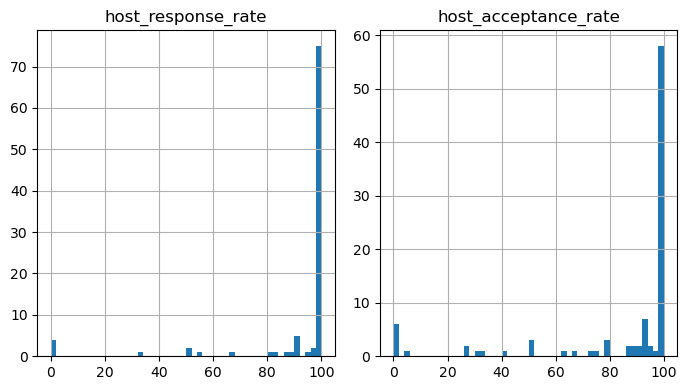

In [205]:
test[host_cols].hist(bins=50, figsize=(7, 4))
plt.tight_layout()
plt.show()

In [206]:
review_cols = [
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value'
]

test[review_cols].describe()

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,100.000000,99.000000,100.000000,99.000000,99.000000,99.00000,99.000000
mean,4.760600,4.810303,4.749700,4.835051,4.882121,4.76303,4.709394
std,0.308394,0.328998,0.322745,0.272027,0.223247,0.28583,0.317859
min,3.000000,3.000000,3.000000,3.000000,3.330000,3.33000,2.670000
25%,4.670000,4.815000,4.670000,4.765000,4.875000,4.69500,4.595000
50%,4.860000,4.900000,4.855000,4.930000,4.950000,4.82000,4.780000
75%,5.000000,5.000000,4.970000,5.000000,5.000000,5.00000,4.900000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000


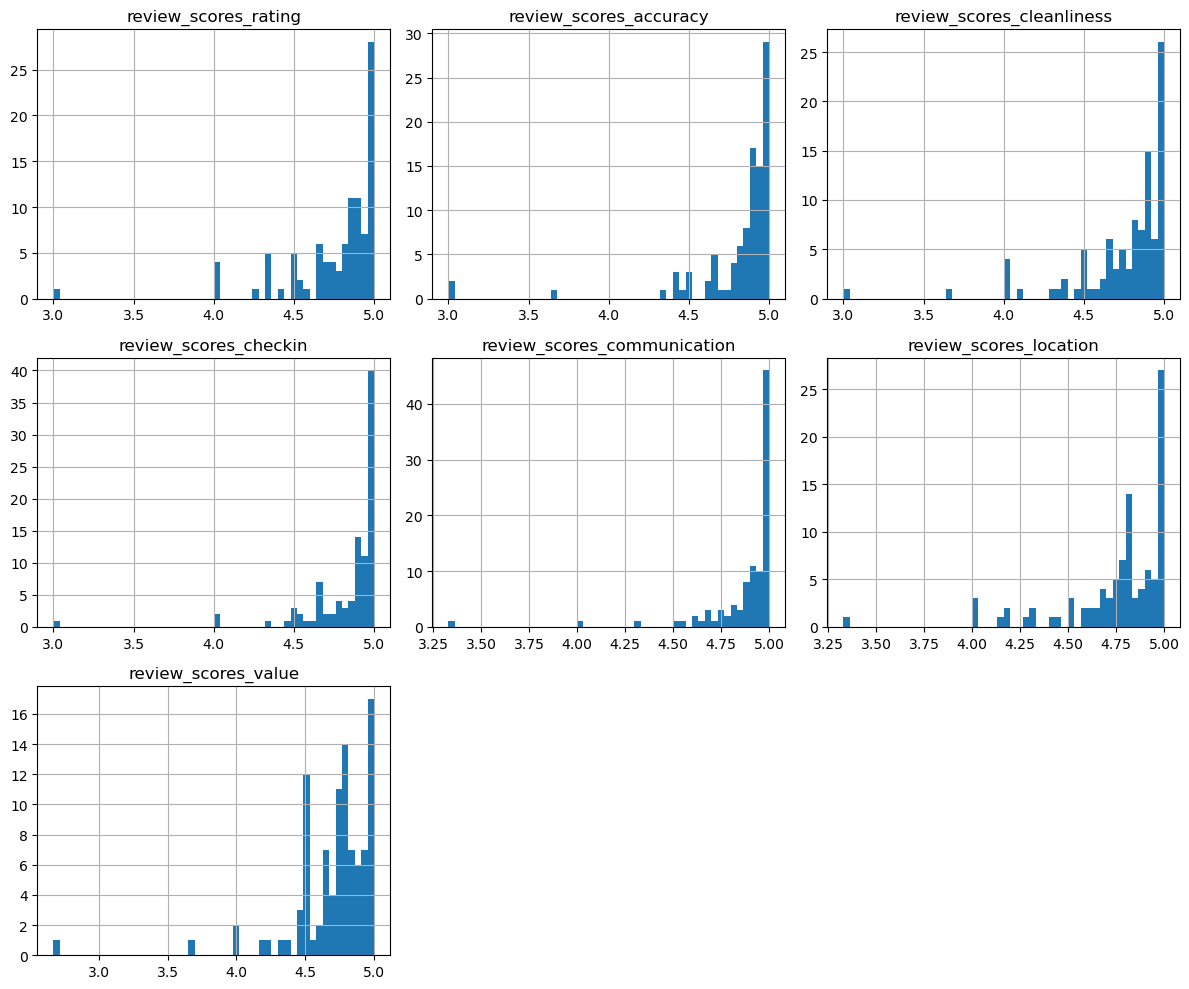

In [207]:
test[review_cols].hist(bins=50, figsize=(12, 10))
plt.tight_layout()
plt.show()

In [208]:
#mean substitution
for col in host_cols:
    test[col] = test[col].fillna(test[col].mean())

In [209]:
#mean substitution
for col in review_cols:
    test[col] = test[col].fillna(test[col].mean())

* review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value
  
--> missing = listing has no reviews --> fill with mean 

##### c. Property attributes 

* price: Numeric variables with skewed distributions --> remove outliers, then substitute by mean
* bedrooms: Use mode
* beds: Use mode

In [210]:
test['price'] = (
    test['price']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)   # <-- remove commas
        .replace('nan', None)
        .astype(float)
)

In [211]:
test["price"].describe()

count       83.000000
mean      2401.795181
std       5951.271264
min         25.000000
25%        110.000000
50%        248.000000
75%       1458.000000
max      39000.000000
Name: price, dtype: float64

In [212]:
# 1. Compute Q3 (75th percentile)
q3_test = test["price"].quantile(0.75)

# 2. Compute mean within Q3 (mean of lower 75% of prices)
q3_mean = test[test["price"] <= q3_test]["price"].mean()

# 3. Replace missing values using this trimmed mean
test["price"] = test["price"].fillna(q3_mean)

In [213]:
test_bedroom_mode = test["bedrooms"].mode() [0]
test_bedroom_mode

1.0

In [214]:
test_bed_mode = test["beds"].mode() [0]
test_bed_mode

2.0

In [215]:
test.fillna({"bedrooms":test_bedroom_mode, "beds":test_bed_mode}, inplace = True)

In [216]:
test.isnull().sum()

host_is_superhost                               130
host_response_rate                                0
host_acceptance_rate                              0
host_total_listings_count                         1
host_has_profile_pic                              1
host_identity_verified                            1
accommodates                                      0
bedrooms                                          0
beds                                              0
price                                             0
minimum_nights                                    0
maximum_nights                                    0
minimum_minimum_nights                            0
maximum_minimum_nights                            0
minimum_maximum_nights                            0
maximum_maximum_nights                            0
minimum_nights_avg_ntm                            0
maximum_nights_avg_ntm                            0
has_availability                                  0
availability

##### d. Behavior variables 

* estimated_revenue_l365d (47 missing)
--> Missing means listing had zero bookings --> behavior signal --> replace by 0 instead of using mean or median

In [217]:
test['estimated_revenue_l365d'] = test['estimated_revenue_l365d'].fillna(0)

* reviews_per_month --> Missing means listing has no reviews --> better replace by 0

In [218]:
test['reviews_per_month'] = test['reviews_per_month'].fillna(0)

In [219]:
test["host_response_time_score"].value_counts()

host_response_time_score
4.0    70
2.0    12
3.0     9
1.0     5
Name: count, dtype: int64

In [220]:
test["host_response_time_score"] = test["host_response_time_score"].fillna(1.0)

##### e. Review recency variables (days_since_first_rv, days_since_last_rv) --> replace by meaningful value

In [221]:
test["days_since_first_rv"].describe()

count     100.000000
mean     1477.950000
std      1260.858489
min         3.000000
25%       376.000000
50%       994.000000
75%      2601.000000
max      4218.000000
Name: days_since_first_rv, dtype: float64

In [222]:
test["days_since_last_rv"].describe()

count     100.00000
mean      463.42000
std       857.09446
min         0.00000
25%        17.00000
50%        59.50000
75%       405.75000
max      3636.00000
Name: days_since_last_rv, dtype: float64

NOTE: days_since_first_rv, days_since_last_rv

--> Missing = listing never reviewed (not just simply mean that there are missing values) 

--> This is a strong negative signal --> replace by an extremly large value (9999)

In [223]:
test['days_since_first_rv'] = test['days_since_first_rv'].fillna(9999)
test['days_since_last_rv'] = test['days_since_last_rv'].fillna(9999)

In [224]:
test.isnull().sum()

host_is_superhost                               130
host_response_rate                                0
host_acceptance_rate                              0
host_total_listings_count                         1
host_has_profile_pic                              1
host_identity_verified                            1
accommodates                                      0
bedrooms                                          0
beds                                              0
price                                             0
minimum_nights                                    0
maximum_nights                                    0
minimum_minimum_nights                            0
maximum_minimum_nights                            0
minimum_maximum_nights                            0
maximum_maximum_nights                            0
minimum_nights_avg_ntm                            0
maximum_nights_avg_ntm                            0
has_availability                                  0
availability

##### f. Other host-related information

In [225]:
test["host_total_listings_count"].mode() [0]

1.0

In [226]:
test["host_has_profile_pic"].mode() [0]

1.0

In [227]:
test["host_identity_verified"].mode() [0]

1.0

In [228]:
test.fillna({"host_total_listings_count": 1, "host_has_profile_pic":1, "host_identity_verified":1}, inplace = True)

#### *Final check

In [229]:
test.isnull().sum()

host_is_superhost                               130
host_response_rate                                0
host_acceptance_rate                              0
host_total_listings_count                         0
host_has_profile_pic                              0
host_identity_verified                            0
accommodates                                      0
bedrooms                                          0
beds                                              0
price                                             0
minimum_nights                                    0
maximum_nights                                    0
minimum_minimum_nights                            0
maximum_minimum_nights                            0
minimum_maximum_nights                            0
maximum_maximum_nights                            0
minimum_nights_avg_ntm                            0
maximum_nights_avg_ntm                            0
has_availability                                  0
availability

### 2. Scaling

#### *Define x and y

In [230]:
test.shape

(130, 50)

In [231]:
test.columns

Index(['host_is_superhost', 'host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'accommodates', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'calculated_host_listings_count',
     

In [232]:
y1 = test.iloc[:, 0] #host_is_super_host
x1 = test.iloc[:,1:50] #all other columns

In [233]:
y1.name

'host_is_superhost'

In [234]:
x1.columns

Index(['host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'host_has_profile_pic',
       'host_identity_verified', 'accommodates', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'calculated_host_listings_count',
       'calculated_host_li

In [235]:
x1.shape #there is no Hotel room type as given in our internal dataset

(130, 49)

In [236]:
x1["room_type_Hotel room"] = 0

In [237]:
x1.head()

,host_response_rate,host_acceptance_rate,host_total_listings_count,host_has_profile_pic,host_identity_verified,accommodates,bedrooms,beds,price,minimum_nights,...,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,days_since_first_rv,days_since_last_rv,bathrooms_number,host_response_time_score,room_type_Private room,room_type_Shared room,room_type_Hotel room
0,100.000000,78.000000,1.0,0.0,0.0,2,1.0,2.0,306.725806,2,...,0,0.45,8,267.0,41.0,2.0,4.0,0,0,0
1,91.927083,83.916667,1.0,1.0,1.0,3,1.0,2.0,306.725806,4,...,0,0.00,40,9999.0,9999.0,1.0,1.0,0,0,0
2,50.000000,50.000000,22.0,1.0,1.0,2,1.0,1.0,47.000000,60,...,0,0.73,34,2461.0,63.0,1.0,2.0,0,0,0
3,100.000000,100.000000,26.0,1.0,1.0,4,2.0,2.0,88.000000,1,...,0,3.80,48,1349.0,128.0,1.0,4.0,0,0,0
4,100.000000,100.000000,53.0,1.0,1.0,8,3.0,3.0,87.000000,2,...,0,2.07,26,2435.0,16.0,2.0,4.0,0,0,0


In [238]:
cols = x1.columns.tolist()
cols

['host_response_rate',
 'host_acceptance_rate',
 'host_total_listings_count',
 'host_has_profile_pic',
 'host_identity_verified',
 'accommodates',
 'bedrooms',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'has_availability',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'instant_bookable',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_room

In [239]:
cols[49]

'room_type_Hotel room'

In [240]:
cols1 = cols[0:47] + [cols[49]] + cols [47:49]
print(cols1)

['host_response_rate', 'host_acceptance_rate', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'accommodates', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_sha

In [241]:
x2 = x1[cols1]
x2.head()

,host_response_rate,host_acceptance_rate,host_total_listings_count,host_has_profile_pic,host_identity_verified,accommodates,bedrooms,beds,price,minimum_nights,...,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,days_since_first_rv,days_since_last_rv,bathrooms_number,host_response_time_score,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,100.000000,78.000000,1.0,0.0,0.0,2,1.0,2.0,306.725806,2,...,0,0.45,8,267.0,41.0,2.0,4.0,0,0,0
1,91.927083,83.916667,1.0,1.0,1.0,3,1.0,2.0,306.725806,4,...,0,0.00,40,9999.0,9999.0,1.0,1.0,0,0,0
2,50.000000,50.000000,22.0,1.0,1.0,2,1.0,1.0,47.000000,60,...,0,0.73,34,2461.0,63.0,1.0,2.0,0,0,0
3,100.000000,100.000000,26.0,1.0,1.0,4,2.0,2.0,88.000000,1,...,0,3.80,48,1349.0,128.0,1.0,4.0,0,0,0
4,100.000000,100.000000,53.0,1.0,1.0,8,3.0,3.0,87.000000,2,...,0,2.07,26,2435.0,16.0,2.0,4.0,0,0,0


## C. Prediction

In [242]:
y_pred = rf_model.predict(x2)

In [243]:
test["Predicted_host_is_superhost"] = y_pred

In [244]:
test.head()

,host_is_superhost,host_response_rate,host_acceptance_rate,host_total_listings_count,host_has_profile_pic,host_identity_verified,accommodates,bedrooms,beds,price,...,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,days_since_first_rv,days_since_last_rv,bathrooms_number,host_response_time_score,room_type_Private room,room_type_Shared room,Predicted_host_is_superhost
0,NaN,100.000000,78.000000,1.0,0.0,0.0,2,1.0,2.0,306.725806,...,0,0.45,8,267.0,41.0,2.0,4.0,0,0,1.0
1,NaN,91.927083,83.916667,1.0,1.0,1.0,3,1.0,2.0,306.725806,...,0,0.00,40,9999.0,9999.0,1.0,1.0,0,0,0.0
2,NaN,50.000000,50.000000,22.0,1.0,1.0,2,1.0,1.0,47.000000,...,0,0.73,34,2461.0,63.0,1.0,2.0,0,0,1.0
3,NaN,100.000000,100.000000,26.0,1.0,1.0,4,2.0,2.0,88.000000,...,0,3.80,48,1349.0,128.0,1.0,4.0,0,0,1.0
4,NaN,100.000000,100.000000,53.0,1.0,1.0,8,3.0,3.0,87.000000,...,0,2.07,26,2435.0,16.0,2.0,4.0,0,0,1.0


In [247]:
test.to_excel("[BAII]Group9_Project2_Test_Prediction.xlsx", index=False) 